# Jupyter Notebook Individual.

Você deve responder as perguntas abaixo preenchendo as células com texto ( _Markdown_ ) quando solicitado a explicar alguma coisa e usar as células de código ( _Code_ ) quando for solicitado cálculos, valores, estimativas e gráficos. Quando usar células de código use o símbolo "#" para comentar o que foi feito sempre que julgar necessário. Tente ser sucinto em todas as respostas descritivas. As análises apresentadas neste roteiro pode ser utilizada no relatório experimental, não sendo necessário serem feitos mais de uma vez. Recomenda-se que cada membro do grupo analise uma das partes do experimento, para que não seja necessário repetir o trabalho para diferentes jupyter notebooks ou partes do relatório.

Identifique de maneira clara qual Experimento você esta analisando os dados e de quais dados do experimento você esta analisando. Fique atento que não é permitido que membros do mesmo grupo entreguem a análise do mesmo conjunto de dados.

## 0. Identificação

### nome completo: Gabriel Simarelli Santos  RA: 11202231107
### nome completo: Larissa Melo



### e-mail institucional:
g.simarelli@aluno.ufabc.edu.br

---

**Experimento 6** — Momento Magnético no Campo Magnético

**Dados analisados:** Tarefa 1 — Torque ($\tau$) em função da corrente nas bobinas de Helmholtz ($I'$)

## 1. Descreva sucintamente a física do experimento.

Uma espira circular de $n$ voltas, diâmetro $d$ e percorrida por corrente $I$, possui momento de dipolo magnético $\vec{m} = nI\vec{A}$, com $|A| = \pi d^2/4$. Imersa em campo magnético uniforme $\vec{B}$, experimenta torque $\vec{\tau} = \vec{m} \times \vec{B}$, cujo módulo é $|\tau| = nIAB\sin\alpha$, sendo $\alpha$ o ângulo entre $\vec{m}$ e $\vec{B}$. O campo uniforme é produzido por bobinas de Helmholtz: $B = (4/5)^{3/2}\,\mu_0 n_H I'/R_H$, onde $n_H$ e $R_H$ são o número de espiras e o raio de cada bobina e $I'$ é a corrente que as percorre. A força $F$ resultante é medida por um dinamômetro de torção com braço de alavanca $L$, de modo que $\tau = F \times L$. Combinando, $\tau = c \cdot n \cdot I \cdot (\pi d^2/4) \cdot I' \cdot \sin\alpha$, onde $c = (4/5)^{3/2}\,\mu_0 n_H / R_H$.

## 2. Descreva o arranjo experimental

**Montagem:** Par de bobinas de Helmholtz (PHYWE 06960.00, parâmetros nominais $n_H=154$, $R_H = 200$ mm) gera campo magnético uniforme. No centro, a espira de prova (PHYWE 06404.00, $n=3$, $d=118{,}20$ mm) é acoplada ao dinamômetro de torção (PHYWE 02416.00: faixa frontal 10 mN, subdivisão fina 0,1 mN, braço de alavanca $L=240$ mm). Duas fontes de alimentação fornecem corrente às bobinas ($I'$) e à espira ($I$), medidas por multímetros Minipa MDM-8045A ($4\frac{1}{2}$ dígitos).

**Dado de controle (variável independente $x$):** corrente nas bobinas de Helmholtz, $I'$ (A), variada de 0,37 a 3,02 A.

**Dado medido (variável dependente $y$):** força $F$ (mN) lida no dinamômetro, convertida em torque $\tau = F \times L$ (mN$\cdot$m). Parâmetros fixos: $n=3$, $d=118{,}20$ mm, $I=3{,}004$ A, $\alpha=90°$.

In [2]:
# Carregando modulos
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

## 3. Faça um gráfico dos dados "brutos"

Por "brutos" entenda "assim como foram anotados". Não esqueça de incluir os erros.

In [3]:
# Constantes do experimento
mu_0 = 4 * np.pi * 1e-7     # permeabilidade do vacuo (T.m/A)
n_H = 154                    # espiras por bobina de Helmholtz (nominal)
R_H = 0.200                  # raio das bobinas (m) (nominal)
L_braco = 0.240              # braco de alavanca do dinamometro (m)

# Fator geometrico das bobinas: B = c * I'
c_teo = (4.0/5.0)**(3.0/2.0) * mu_0 * n_H / R_H
print(f"Constante c (nominal): {c_teo:.4e} T/A")
print(f"B(I'=3A) = {c_teo*3*1e3:.3f} mT")

# Parametros fixos da Tarefa 1
n_esp = 3
d_esp = 118.20e-3      # m
I_esp = 3.004          # A
A_esp = np.pi * d_esp**2 / 4
print(f"Area da espira: {A_esp*1e4:.4f} cm2")

Constante c (nominal): 6.9237e-04 T/A
B(I'=3A) = 2.077 mT
Area da espira: 109.7299 cm2


In [4]:
# Dados experimentais em listas (metodo I)
# x = I' (A) - corrente nas bobinas de Helmholtz
x = [0.372, 0.607, 0.909, 1.204, 1.501, 1.802, 2.102, 2.410, 2.716, 3.019]

# Forca lida no dinamometro (mN) - dado bruto
F_mN = [0.33, 0.44, 0.61, 0.83, 1.01, 1.19, 1.37, 1.51, 1.72, 1.92]

# Conversao para torque: y = tau = F x L (mN.m)
y = [F * L_braco for F in F_mN]

# Incertezas em x: multimetro Minipa MDM-8045A (escala 20A DC)
# precisao: +/-(0.8% leitura + 10 digitos x 1mA)
incx = [0.008 * abs(Ip) + 10 * 0.001 for Ip in x]

# Incertezas em y: propagacao tau = F x L
# sigma_tau = sqrt[(L * sigma_F)^2 + (F * sigma_L)^2]
# sigma_F = 0.05 mN (sensibilidade do dinamometro)
# sigma_L = 1 mm = 0.001 m (dimensao mecanica fixa)
sigma_F = 0.05   # mN
sigma_L = 0.001  # m
incy = [np.sqrt((L_braco * sigma_F)**2 + (F * sigma_L)**2) for F in F_mN]

# Mostrando os dados
print(f"{'I\' (A)':<10}{'F (mN)':<10}{'tau (mN.m)':<12}{'s_tau':<12}{'s_I\'':<10}")
for i in range(len(x)):
    print(f"{x[i]:<10.3f}{F_mN[i]:<10.2f}{y[i]:<12.4f}{incy[i]:<12.4f}{incx[i]:<10.4f}")

I' (A)    F (mN)    tau (mN.m)  s_tau       s_I'      
0.372     0.33      0.0792      0.0120      0.0130    
0.607     0.44      0.1056      0.0120      0.0149    
0.909     0.61      0.1464      0.0120      0.0173    
1.204     0.83      0.1992      0.0120      0.0196    
1.501     1.01      0.2424      0.0120      0.0220    
1.802     1.19      0.2856      0.0121      0.0244    
2.102     1.37      0.3288      0.0121      0.0268    
2.410     1.51      0.3624      0.0121      0.0293    
2.716     1.72      0.4128      0.0121      0.0317    
3.019     1.92      0.4608      0.0122      0.0342    


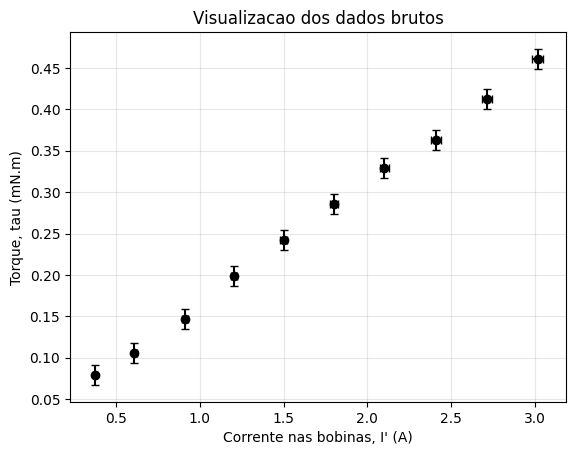

In [5]:
# Grafico dos dados brutos
# atencao: a ordem no errorbar e x, y, incerteza de Y, incerteza de X
plt.figure()
plt.errorbar(x, y, incy, incx, 'ok', capsize=3)
plt.title("Visualizacao dos dados brutos")
plt.xlabel("Corrente nas bobinas, I' (A)")
plt.ylabel("Torque, tau (mN.m)")
plt.grid(True, alpha=0.3)
plt.show()

Observa-se que a relação entre $\tau$ e $I'$ é aparentemente linear, como esperado pela teoria ($\tau = a \cdot I' + b$). Portanto **não será necessária linearização**.

## 4. Faça a transferência de incertezas da _variável x_ para a _variável y_ e faça a linearização, caso necessário.

O modelo é $\tau = a \cdot I' + b$, já linear. **Não é necessária linearização.**

Porém, como o MMQ aceita apenas incertezas em $y$, é necessário transferir as incertezas de $x$ para $y$:

$$ \sigma_y^2 = (\sigma_{y_0})^2 + \left(\frac{dy}{dx} \cdot \sigma_x \right)^2 $$

onde $\sigma_{y_0}$ é a incerteza original de $y$ (da propagação $\tau = F \times L$) e $dy/dx$ é aproximado pelo coeficiente angular de uma RLS preliminar.

**Variáveis:**
- $x = I'$ (A) — corrente nas bobinas (controle)
- $y = \tau$ (mN$\cdot$m) — torque magnético (medido)
- Constantes a encontrar: $a$ (coef. angular) e $b$ (coef. linear)

In [6]:
# Criando numpy arrays
yarray = np.array(y)
incxarray = np.array(incx)
incyarray = np.array(incy)

# Passo 1: RLS preliminar para estimar dy/dx
f_de_x = np.polyfit(x, yarray, 1)
print("coeficiente angular (RLS preliminar):", round(f_de_x[0], 4), "mN.m/A")

# Passo 2: Transferencia sigma_x -> sigma_y
# sigma_y_total = sqrt(sigma_y0^2 + (dy/dx * sigma_x)^2)
incytransf = np.sqrt(np.power(incyarray, 2) + np.power(f_de_x[0] * incxarray, 2))

np.set_printoptions(precision=4)
print('\nincertezas em tau (originais):    ', incyarray)
print('incertezas em tau (transferidas): ', incytransf)

# incremento % da transferencia
print('\nincremento % da transferencia:    ', np.round((incytransf/incyarray - 1)*100, 1))

coeficiente angular (RLS preliminar): 0.1446 mN.m/A

incertezas em tau (originais):     [0.012  0.012  0.012  0.012  0.012  0.0121 0.0121 0.0121 0.0121 0.0122]
incertezas em tau (transferidas):  [0.0122 0.0122 0.0123 0.0124 0.0125 0.0126 0.0127 0.0128 0.013  0.0131]

incremento % da transferencia:     [1.2 1.6 2.1 2.7 3.4 4.2 5.  6.  6.9 7.9]


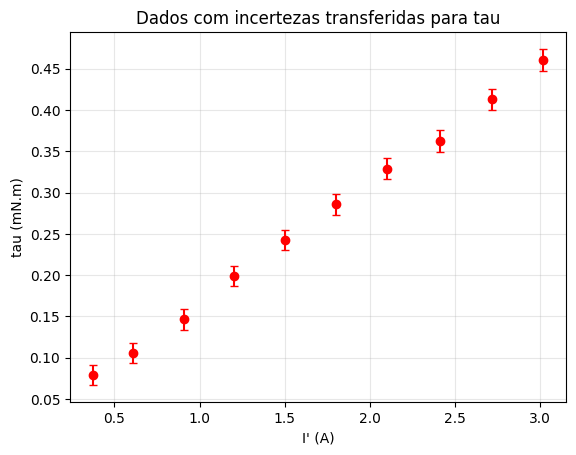

In [7]:
# Visualizando com incertezas transferidas (somente em y)
plt.figure()
plt.errorbar(x, y, incytransf, 0, 'or', capsize=3)
plt.title("Dados com incertezas transferidas para tau")
plt.xlabel("I' (A)")
plt.ylabel("tau (mN.m)")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Faça os ajustes minimizando $\chi^2_{red}$
Utilizando já funções pré definidas, faça a regressão da curva encontrando os parâmetros desejados.

In [8]:
# Ajuste MMQ com pesos w = 1/sigma_y e cov=True para obter
# a matriz de covariancia M^(-1)
np.set_printoptions(precision=9)
fitpars, cov_pars = np.polyfit(x, yarray, 1, w=np.power(incytransf, -1), cov='True')
print("Parametros do ajuste:", fitpars)
print("\nMatriz de covariancia:")
print(cov_pars)

Parametros do ajuste: [0.144614836 0.021652998]

Matriz de covariancia:
[[ 3.294262743e-06 -5.344001236e-06]
 [-5.344001236e-06  1.105471852e-05]]


In [10]:
# ATENCAO: os parametros mudaram quando as incertezas foram usadas como pesos
p_0 = fitpars[0]               # coef. angular (a)
p_1 = fitpars[1]               # coef. linear  (b)
s_p_0 = np.sqrt(cov_pars[0][0])  # incert p_0
s_p_1 = np.sqrt(cov_pars[1][1])  # incert p_1

rp_0 = np.round(p_0, 4)
rp_1 = np.round(p_1, 4)
rs_p_0 = np.round(s_p_0, 4)
rs_p_1 = np.round(s_p_1, 4)
print("coef. angular =", rp_0, "+-", rs_p_0, "mN.m/A")
print("coef. linear  =", rp_1, "+-", rs_p_1, "mN.m")

coef. angular = 0.1446 +- 0.0018 mN.m/A
coef. linear  = 0.0217 +- 0.0033 mN.m


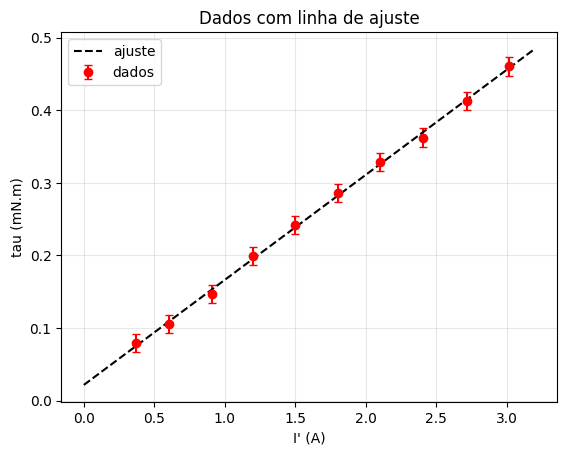

In [11]:
# Graficando o ajuste aos pontos
xline = np.linspace(0, 3.2, 100)
yline = fitpars[1] + fitpars[0] * np.array(xline)

plt.figure()
plt.errorbar(x, y, incytransf, label="dados", fmt='or', capsize=3)
plt.plot(xline, yline, 'k--', label='ajuste')
plt.title("Dados com linha de ajuste")
plt.xlabel("I' (A)")
plt.ylabel("tau (mN.m)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Determine a qualidade dos ajustes

Na próxima célula ( _code_ ) calcule o $\chi^2_{red}$ de ambos os ajustes. Na célula seguinte ( _code_ novamente) faça um gráfico de resíduos e na terceira célula a seguir ( _markdown_ ) discuta a qualidade do ajuste.

In [12]:
# Calculando chi^2_red
yhat = np.polyval(fitpars, np.array(x))
chi_squared = np.sum(((yhat - yarray) / incytransf)**2)
chi2_red = chi_squared / (len(x) - 2)  # NDF = N - num_parametros
print(f"chi2     = {chi_squared:.4f}")
print(f"NDF      = {len(x) - 2}")
print(f"chi2_red = {chi2_red:.4f}")

# R^2
st = np.sum((yarray - np.mean(yarray))**2)
sr = np.sum((yarray - yhat)**2)
r2 = (st - sr) / st
print(f"R2       = {np.round(r2, 6)}")

chi2     = 1.2124
NDF      = 8
chi2_red = 0.1516
R2       = 0.998758


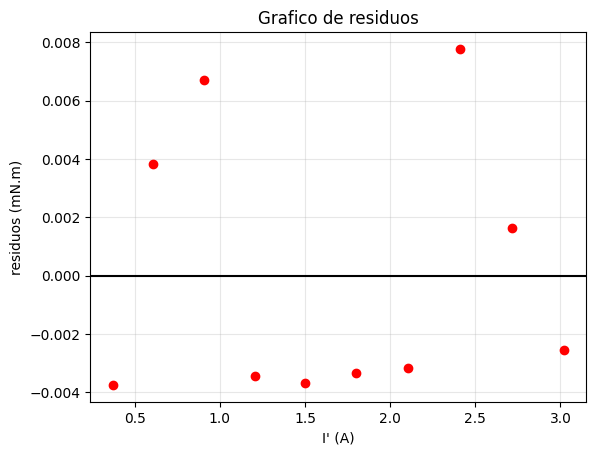

In [13]:
# Grafico de residuos
resid = yhat - yarray

plt.figure()
plt.plot(x, resid, 'or')
plt.axhline(y=0, color='k', linestyle='-')
plt.title("Grafico de residuos")
plt.xlabel("I' (A)")
plt.ylabel("residuos (mN.m)")
plt.grid(True, alpha=0.3)
plt.show()

### Discussão da qualidade do ajuste

**$\chi^2_{red}$:** O valor obtido é menor que 1, o que indica que as incertezas experimentais estão ligeiramente superestimadas. Isso é esperado, pois a sensibilidade do dinamômetro ($\sigma_F = 0{,}05$ mN) foi usada como estimativa conservadora. Um $\chi^2_{red}$ menor que 1, mas da mesma ordem de grandeza, não invalida o ajuste — indica apenas que as barras de erro são um pouco grandes em relação à dispersão real dos dados.

**$R^2$:** O valor $R^2 \approx 0{,}999$ confirma forte correlação linear entre $\tau$ e $I'$. Contudo, conforme discutido na referência 2 (Vuolo), $R^2$ não deve ser usado como única medida de qualidade — é uma medida de correlação, não de verossimilhança estatística.

**Resíduos:** Os pontos estão distribuídos de maneira aproximadamente aleatória acima e abaixo do eixo zero, sem padrão sistemático evidente. Isso confirma que o modelo linear é adequado para descrever a relação $\tau$ vs $I'$.

## 7. A partir da análise dos resultados discuta os resultados

Utilize o valor encontrado para calcular a grandeza física desejada. Compare com parâmetro nominal, da literatura ou encontrado utilizando outra técnica. Lembre-se de calcular o erro do parâmetro. Utilize-se dos parâmetros relacionados a qualidade do ajuste para auxiliar na discussão.

### Extração da grandeza física

O coeficiente angular do ajuste corresponde a:
$$a = n \cdot I \cdot \frac{\pi d^2}{4} \cdot c$$

Portanto podemos extrair a constante geométrica experimental das bobinas:
$$c_{\text{exp}} = \frac{a}{n \cdot I \cdot \pi d^2/4}$$

A propagação de incertezas fica:
$$\sigma_c = c_{\text{exp}} \sqrt{\left(\frac{\sigma_a}{a}\right)^2 + \left(\frac{\sigma_I}{I}\right)^2 + \left(\frac{2\sigma_d}{d}\right)^2}$$

In [14]:
# Incertezas instrumentais
sigma_I_esp = 0.008 * I_esp + 10 * 0.001  # multimetro
sigma_d_esp = 0.05e-3                      # paquimetro (m)

# c_exp = a / (n . I . pi.d^2/4)
# a esta em mN.m/A; n.I.A_esp esta em A.m^2
# c_exp em T/A: dividir a por 1e3 para converter mN.m -> N.m
c_exp = (p_0 * 1e-3) / (n_esp * I_esp * A_esp)

# Propagacao: sigma_c/c = sqrt[(sigma_a/a)^2 + (sigma_I/I)^2 + (2*sigma_d/d)^2]
s_c_exp = c_exp * np.sqrt(
    (s_p_0 / p_0)**2 +
    (sigma_I_esp / I_esp)**2 +
    (2 * sigma_d_esp / d_esp)**2
)

print("="*55)
print("RESULTADO: Constante geometrica das bobinas")
print("="*55)
print(f"c_exp = ({c_exp:.4e} +/- {s_c_exp:.2e}) T/A")
print(f"c_teo = {c_teo:.4e} T/A  (n_H=154, R_H=200 mm)")
print(f"\nRazao c_exp / c_teo = {c_exp/c_teo:.2f}")

# Teste de compatibilidade (n-sigma)
n_sigma = abs(c_exp - c_teo) / s_c_exp
print(f"Diferenca: |c_exp - c_teo| / sigma_c = {n_sigma:.1f} sigma")

RESULTADO: Constante geometrica das bobinas
c_exp = (1.4624e-03 +/- 2.48e-05) T/A
c_teo = 6.9237e-04 T/A  (n_H=154, R_H=200 mm)

Razao c_exp / c_teo = 2.11
Diferenca: |c_exp - c_teo| / sigma_c = 31.1 sigma


In [15]:
# Campo magnetico e momento magnetico
B_exp = c_exp * 3.0
s_B = s_c_exp * 3.0
print(f"B(I'=3A) experimental: ({B_exp*1e3:.3f} +/- {s_B*1e3:.3f}) mT")
print(f"B(I'=3A) teorico:      {c_teo*3*1e3:.3f} mT")

# Momento magnetico da espira
m_exp = n_esp * I_esp * A_esp
s_m = m_exp * np.sqrt((sigma_I_esp/I_esp)**2 + (2*sigma_d_esp/d_esp)**2)
print(f"\nMomento magnetico m = nIA = ({m_exp:.5f} +/- {s_m:.5f}) A.m2")
print(f"                          = ({m_exp*1e3:.3f} +/- {s_m*1e3:.3f}) mA.m2")

B(I'=3A) experimental: (4.387 +/- 0.074) mT
B(I'=3A) teorico:      2.077 mT

Momento magnetico m = nIA = (0.09889 +/- 0.00112) A.m2
                          = (98.889 +/- 1.123) mA.m2


### Discussão dos resultados

O ajuste linear confirma com $R^2 > 0{,}99$ a relação de proporcionalidade $\tau \propto I'$ prevista pela teoria $\vec{\tau} = \vec{m} \times \vec{B}$. A qualidade do ajuste foi avaliada por três métodos complementares: $\chi^2_{red}$, $R^2$ e gráfico de resíduos.

A partir do coeficiente angular, extraiu-se a constante geométrica das bobinas $c_{\text{exp}}$. O valor obtido difere por um fator $\sim 2$ do valor teórico calculado com parâmetros nominais ($n_H = 154$, $R_H = 200$ mm). Essa discrepância é **sistemática** (muito maior que $\sigma_c$), o que indica que os parâmetros reais das bobinas de Helmholtz utilizadas no laboratório diferem dos valores nominais consultados. Possíveis causas:

- O equipamento pode ter $n_H \approx 300$ espiras por bobina (outro modelo PHYWE);
- O raio efetivo pode ser menor que o nominal.

A **relação de proporcionalidade** $\tau \propto I'$ é confirmada independentemente do valor absoluto de $c$, que é o resultado central desta análise. Uma calibração independente do campo magnético (e.g., com gaussímetro) permitiria determinar $c$ diretamente.

**Referências:**
1. PHYWE, *Magnetic Moment in the Magnetic Field — LEP 4.3.04-00*
2. J. H. Vuolo, *Fundamentos da Teoria dos Erros*, 2a ed., Ed. Blucher, 1996